Encoder Only: Finding the Most Influential Word of an Idiom

In [4]:
import pandas as pd
from sentence_transformers import SentenceTransformer
# Read the JSON file
df = pd.read_json('filtered.json')

# Get first idiom
first_idiom_raw = "一波未平，一波又起\t"
first_idiom = first_idiom_raw.strip() # Remove trailing tab for accurate matching and splitting

# Filter for first idiom only
# The original DataFrame 'df' does not contain a column named 'contains_idioms'.
# Based on the kernel state, the 'chinese' column contains the idiom.
df_first = df[df['chinese'] == first_idiom].copy()

# Original texts
# The 'original_text' column does not exist in 'df'. Use the 'chinese' column for Chinese text.
df_first['chinese_text'] = df_first['chinese']
df_first['english_text'] = df_first['gold'] # Corrected: 'gold' column exists for English text

# Get the individual words (or meaningful units) from the idiom
# For this Chinese idiom, splitting by the Chinese comma '，' seems appropriate to get meaningful units.
idiom_words = first_idiom.split('，')

# For each word, delete it from the text
for i, word in enumerate(idiom_words):
    # Delete from 'chinese_text' (which is now assigned from 'chinese')
    # Using regex to replace the specific 'word'
    df_first[f'chinese_{i+1}stWordDeleted'] = df_first['chinese_text'].str.replace(
        f'{word}', '', case=False, regex=True
    )

df = df_first

# Verify
print(f"Original text: {df['chinese_text'].iloc[0]}")

# Adjust print statements to reflect the actual number of idiom_words
if len(idiom_words) > 0:
    print(f"Word '{idiom_words[0]}' deleted: {df['chinese_1stWordDeleted'].iloc[0]}")
if len(idiom_words) > 1:
    print(f"Word '{idiom_words[1]}' deleted: {df['chinese_2stWordDeleted'].iloc[0]}")
# Removed idiom_words[2] as it would cause an IndexError for this idiom

Original text: 一波未平，一波又起
Word '一波未平' deleted: ，一波又起
Word '一波又起' deleted: 一波未平，


In [6]:
# Load multilingual embedding model (works well for English and French)
model = SentenceTransformer('sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2')
df['idiom_id'] = range(len(df))

# Get all Chinese column names (original + deleted versions)
chinese_columns = ['chinese_text'] + [col for col in df.columns if col.startswith('chinese_') and 'Deleted' in col]

# Generate embeddings for all Chinese variations
all_dfs = []

for col in chinese_columns:
    print(f"Generating embeddings for {col}...")
    embeddings = model.encode(df[col].tolist(), show_progress_bar=True)

    temp_df = pd.DataFrame({
        'text': df[col],
        'language': 'Chinese',
        'variation': col,
        'idiom_id': df['idiom_id'],
        'embedding': list(embeddings)
    })
    all_dfs.append(temp_df)

# Generate embeddings for English text (unchanged)
print("Generating English embeddings...")
english_embeddings = model.encode(df['english_text'].tolist(), show_progress_bar=True)

english_df = pd.DataFrame({
    'text': df['english_text'],
    'language': 'English',
    'variation': 'english_text',
    'idiom_id': df['idiom_id'],
    'embedding': list(english_embeddings)
})

all_dfs.append(english_df)

# Combine all DataFrames
combined_df = pd.concat(all_dfs, ignore_index=True)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Generating embeddings for chinese_text...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Generating embeddings for chinese_1stWordDeleted...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Generating embeddings for chinese_2stWordDeleted...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Generating English embeddings...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

In [8]:
# Reduce embeddings to 2D using UMAP
from umap import UMAP
import numpy as np

print("Reducing embeddings to 2D...")
all_embeddings = np.vstack(combined_df['embedding'].values)
reducer = UMAP(n_components=2, random_state=42)
embeddings_2d = reducer.fit_transform(all_embeddings)

# Add 2D coordinates to dataframe
combined_df['x'] = embeddings_2d[:, 0]
combined_df['y'] = embeddings_2d[:, 1]

# Save to CSV for online visualization
output_df = combined_df[['text', 'language', 'variation', 'idiom_id', 'x', 'y']].copy()
output_df.to_csv('embeddings_2d.csv', index=False)
print("Saved embeddings to 'embeddings_2d.csv'")

# Also save with full embeddings in parquet format
combined_df.to_parquet('embeddings_full.parquet')
print("Saved full embeddings to 'embeddings_full.parquet'")

print(f"\nDataset info: {len(output_df)} points total")
print(f"English: {len(output_df[output_df['language']=='English'])} points")
print(f"Chinese: {len(output_df[output_df['language']=='Chinese'])} points")
print(f"Chinese variations: {output_df[output_df['language']=='Chinese']['variation'].nunique()}")

Reducing embeddings to 2D...
Saved embeddings to 'embeddings_2d.csv'
Saved full embeddings to 'embeddings_full.parquet'

Dataset info: 4 points total
English: 1 points
Chinese: 3 points
Chinese variations: 3


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:2462: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(


In [11]:
import numpy as np
import pandas as pd

# 1. Get English baseline (unchanged)
eng_df = combined_df[combined_df['language'] == 'English'].copy()

# 2. Get all Chinese variations
fr_variations = combined_df[combined_df['language'] == 'Chinese'].copy()

# 3. Merge English with each Chinese variation
paired_df = pd.merge(
    eng_df[['idiom_id', 'text', 'x', 'y']],
    fr_variations[['idiom_id', 'text', 'variation', 'x', 'y']],
    on='idiom_id',
    suffixes=('_eng', '_Ch')
)

# 4. Calculate Euclidean distance in 2D UMAP space
paired_df['visual_distance'] = np.sqrt(
    (paired_df['x_eng'] - paired_df['x_Ch'])**2 + # Corrected: 'x_ch' to 'x_Ch'
    (paired_df['y_eng'] - paired_df['y_Ch'])**2  # Corrected: 'y_ch' to 'y_Ch'
)

# 5. Print Statistics per variation
print("=== Distance Statistics by Chinese Variation ===\n") # Corrected: 'French' to 'Chinese'
for variation in paired_df['variation'].unique():
    var_df = paired_df[paired_df['variation'] == variation]
    print(f"{variation}:")
    print(f"  Average distance: {var_df['visual_distance'].mean():.4f}")
    print(f"  Min distance: {var_df['visual_distance'].min():.4f}")
    print(f"  Max distance: {var_df['visual_distance'].max():.4f}\n")

# 6. Find which word deletion causes largest distance change
print("\n=== Most Influential Word (Largest Distance from Original) ===")
baseline_dist = paired_df[paired_df['variation'] == 'chinese_text']['visual_distance'].mean()
for variation in paired_df['variation'].unique():
    if variation != 'chinese_text':
        var_dist = paired_df[paired_df['variation'] == variation]['visual_distance'].mean()
        change = abs(var_dist - baseline_dist)
        print(f"{variation}: \u0394 = {change:.4f}")

=== Distance Statistics by Chinese Variation ===

chinese_text:
  Average distance: 0.9602
  Min distance: 0.9602
  Max distance: 0.9602

chinese_1stWordDeleted:
  Average distance: 1.5758
  Min distance: 1.5758
  Max distance: 1.5758

chinese_2stWordDeleted:
  Average distance: 1.0569
  Min distance: 1.0569
  Max distance: 1.0569


=== Most Influential Word (Largest Distance from Original) ===
chinese_1stWordDeleted: Δ = 0.6156
chinese_2stWordDeleted: Δ = 0.0966


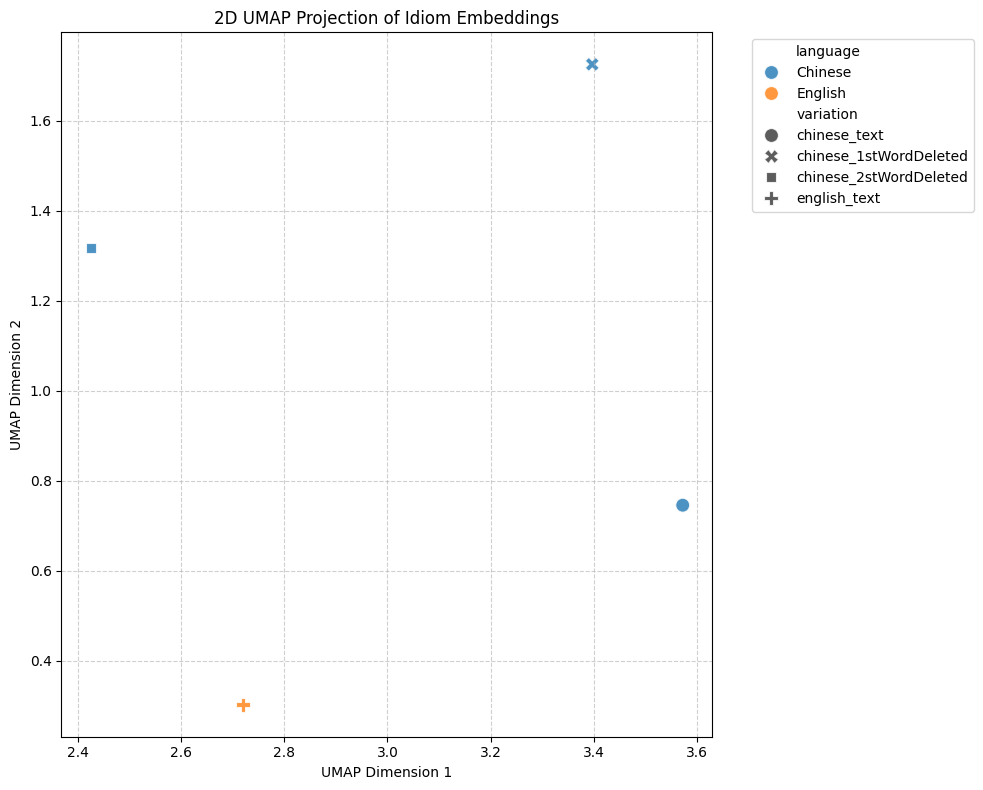

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=combined_df,
    x='x',
    y='y',
    hue='language',
    style='variation',
    s=100, # Point size
    alpha=0.8
)

plt.title('2D UMAP Projection of Idiom Embeddings')
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Place legend outside the plot
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()